In [2]:
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns       
import warnings
warnings.filterwarnings('ignore')  
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

In [3]:
df = pd.read_csv(r"C:\Project\Custome_Churn_Predictor\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset shape: {df.shape}")
print(f"→ {df.shape[0]} customers, {df.shape[1]} columns")

Dataset shape: (7043, 21)
→ 7043 customers, 21 columns


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
print("Churn value counts:")
print(df['Churn'].value_counts())
print()
print(f"Churn rate: {df['Churn'].value_counts()['Yes'] / len(df) * 100:.1f}%")
print()
print("This means ~26.5% of customers left.")
print("This is called CLASS IMBALANCE — more 'No' than 'Yes'.")
print("We'll need to handle this later!")

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%

This means ~26.5% of customers left.
This is called CLASS IMBALANCE — more 'No' than 'Yes'.
We'll need to handle this later!


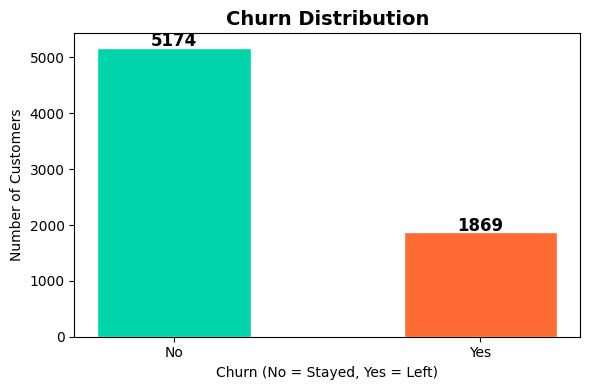

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Churn'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#00D4AA', '#FF6B35'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_xlabel('Churn (No = Stayed, Yes = Left)')
plt.tight_layout()
plt.show()

Churn rate by contract type:
         Contract  Churn Rate (%)
0  Month-to-month       42.709677
1        One year       11.269518
2        Two year        2.831858


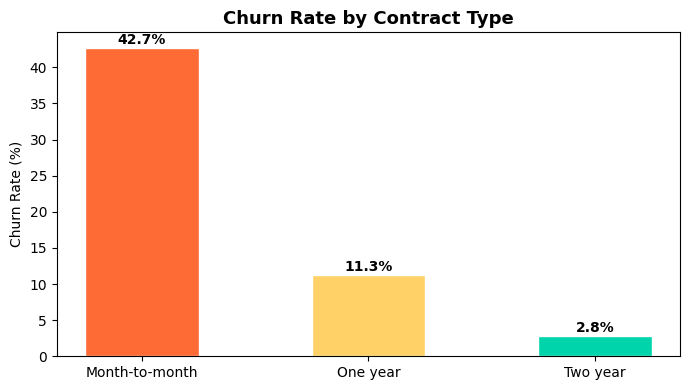


→ Month-to-month customers churn WAY more than annual/biannual customers.
  This will be a very important feature for our model.


In [9]:
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
churn_by_contract.columns = ['Contract', 'Churn Rate (%)']

print("Churn rate by contract type:")
print(churn_by_contract)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#FF6B35', '#FFD166', '#00D4AA']
bars = ax.bar(churn_by_contract['Contract'],
              churn_by_contract['Churn Rate (%)'],
              color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_by_contract['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()
print()
print("→ Month-to-month customers churn WAY more than annual/biannual customers.")
print("  This will be a very important feature for our model.")

Churn rate by how long customer has been with us:
   Tenure Group  Churn Rate (%)
0   0-12 months       47.678161
1  13-24 months       28.710938
2  25-48 months       20.388959
3  49-72 months        9.513176


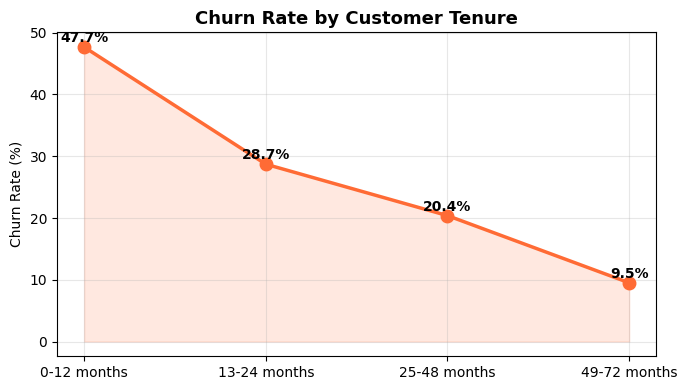


→ New customers (0-12 months) churn the most.
  Once customers pass 2 years, they're much more loyal.


In [10]:
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'])

churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
churn_by_tenure.columns = ['Tenure Group', 'Churn Rate (%)']

print("Churn rate by how long customer has been with us:")
print(churn_by_tenure)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(churn_by_tenure['Tenure Group'],
        churn_by_tenure['Churn Rate (%)'],
        color='#FF6B35', lw=2.5, marker='o', markersize=9)
ax.fill_between(range(len(churn_by_tenure)),
                churn_by_tenure['Churn Rate (%)'],
                alpha=0.15, color='#FF6B35')
for i, val in enumerate(churn_by_tenure['Churn Rate (%)']):
    ax.text(i, val + 0.8, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Customer Tenure', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticks(range(len(churn_by_tenure)))
ax.set_xticklabels(churn_by_tenure['Tenure Group'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print()
print("→ New customers (0-12 months) churn the most.")
print("  Once customers pass 2 years, they're much more loyal.")

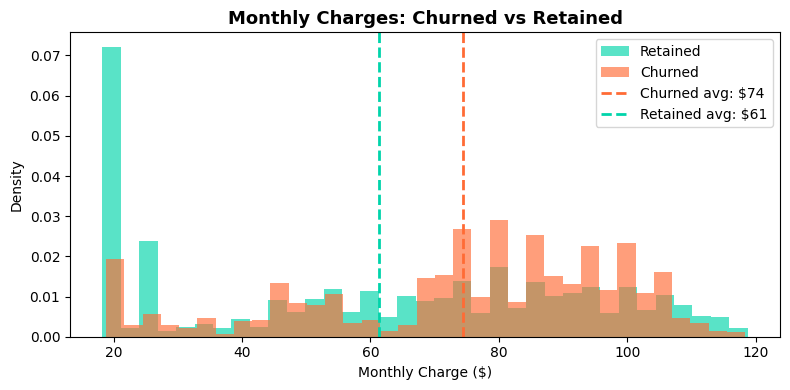


Average monthly charge — Churned  : $74.44
Average monthly charge — Retained : $61.27

→ Customers who churn tend to pay MORE per month.
  High charges + low perceived value = churn risk.


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

churned   = df[df['Churn'] == 'Yes']['MonthlyCharges']
retained  = df[df['Churn'] == 'No']['MonthlyCharges']

ax.hist(retained, bins=35, alpha=0.65, color='#00D4AA', label='Retained', density=True)
ax.hist(churned,  bins=35, alpha=0.65, color='#FF6B35', label='Churned',  density=True)
ax.axvline(churned.mean(),  color='#FF6B35', linestyle='--', lw=2,
           label=f'Churned avg: ${churned.mean():.0f}')
ax.axvline(retained.mean(), color='#00D4AA', linestyle='--', lw=2,
           label=f'Retained avg: ${retained.mean():.0f}')

ax.set_title('Monthly Charges: Churned vs Retained', fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Charge ($)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()
print()
print(f"Average monthly charge — Churned  : ${churned.mean():.2f}")
print(f"Average monthly charge — Retained : ${retained.mean():.2f}")
print()
print("→ Customers who churn tend to pay MORE per month.")
print("  High charges + low perceived value = churn risk.")

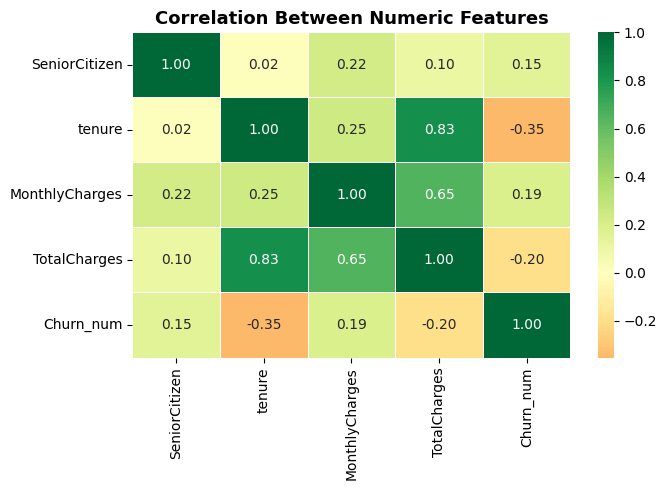

In [13]:
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')
df_temp['TotalCharges'] = df_temp['TotalCharges'].fillna(df_temp['MonthlyCharges'] * df_temp['tenure'])
df_temp['Churn_num'] = (df_temp['Churn'] == 'Yes').astype(int)
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']
corr = df_temp[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Between Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print("TotalCharges data type:", df['TotalCharges'].dtype)
print()
blank_mask = df['TotalCharges'].str.strip() == ''
print(f"Blank TotalCharges entries: {blank_mask.sum()}")
print()
print("Sample of blank rows:")
print(df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())

TotalCharges data type: object

Blank TotalCharges entries: 11

Sample of blank rows:
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             


In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

print("TotalCharges data type now:", df['TotalCharges'].dtype)
print("Any NaN remaining?", df['TotalCharges'].isna().sum())
print()
print(" TotalCharges is now a proper number column")

TotalCharges data type now: float64
Any NaN remaining? 0

 TotalCharges is now a proper number column


In [17]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else " No missing values!")
print()

df = df.drop(columns=['customerID'])
print(f"Dropped 'customerID'. New shape: {df.shape}")

Missing values per column:
tenure_group    11
dtype: int64

Dropped 'customerID'. New shape: (7043, 21)


In [18]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Churn column after encoding:")
print(df['Churn'].value_counts())
print()
print("0 = Stayed, 1 = Churned")

Churn column after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64

0 = Stayed, 1 = Churned


In [34]:
cat_columns = df.select_dtypes(include='object').columns.tolist()
cat_columns = [c for c in cat_columns if c != 'tenure_group']

print("Text columns being encoded:")
for col in cat_columns:
    print(f"  {col}")

le = LabelEncoder()
for col in cat_columns:
    df[col] = le.fit_transform(df[col].astype(str))

tenure_map = {'0-12 months': 0, '13-24 months': 1, '25-48 months': 2, '49-72 months': 3}
df['tenure_group'] = df['tenure_group'].map(tenure_map).fillna(0).astype(int)
print()

df.head()

Text columns being encoded:



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,0,1,2,29.85,29.85,0,0
1,1,0,0,0,34,1,0,0,2,0,...,0,0,0,1,0,3,56.95,1889.50,0,0
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,108.15,1,0
3,1,0,0,0,45,0,1,0,2,0,...,2,0,0,1,0,0,42.30,1840.75,0,0
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,151.65,1,0


In [35]:
le = LabelEncoder()

for col in cat_columns:
    df[col] = le.fit_transform(df[col].astype(str))

print(" All text columns are now numbers!")
print()
print("First 5 rows after encoding:")
df.head()

 All text columns are now numbers!

First 5 rows after encoding:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,0,1,2,29.85,29.85,0,0
1,1,0,0,0,34,1,0,0,2,0,...,0,0,0,1,0,3,56.95,1889.50,0,0
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,108.15,1,0
3,1,0,0,0,45,0,1,0,2,0,...,2,0,0,1,0,0,42.30,1840.75,0,0
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,151.65,1,0


In [36]:
print("Data types after encoding:")
print(df.dtypes)
print()
print("Any non-numeric columns left?", 
      df.select_dtypes(include='object').shape[1])

Data types after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
tenure_group          int64
dtype: object

Any non-numeric columns left? 0


In [37]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"X shape (features): {X.shape}")
print(f"  → {X.shape[0]} customers, {X.shape[1]} features")
print()
print(f"y shape (target): {y.shape}")
print(f"  → {y.shape[0]} labels (0 or 1)")
print()
print("Feature columns:")
print(list(X.columns))

X shape (features): (7043, 20)
  → 7043 customers, 20 features

y shape (target): (7043,)
  → 7043 labels (0 or 1)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure_group']


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      
    random_state=42,     
    stratify=y           
)

print(f"Training set : {X_train.shape[0]} customers ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} customers ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("Churn rate in training set:", f"{y_train.mean()*100:.1f}%")
print("Churn rate in test set    :", f"{y_test.mean()*100:.1f}%")
print()

Training set : 5634 customers (80%)
Test set     : 1409 customers (20%)

Churn rate in training set: 26.5%
Churn rate in test set    : 26.5%



In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling — MonthlyCharges range:")
print(f"  Min: {X_train['MonthlyCharges'].min():.2f}")
print(f"  Max: {X_train['MonthlyCharges'].max():.2f}")
print()
print("After scaling — MonthlyCharges range:")
mc_idx = list(X_train.columns).index('MonthlyCharges')
print(f"  Min: {X_train_scaled[:, mc_idx].min():.2f}")
print(f"  Max: {X_train_scaled[:, mc_idx].max():.2f}")
print()

Before scaling — MonthlyCharges range:
  Min: 18.40
  Max: 118.75

After scaling — MonthlyCharges range:
  Min: -1.54
  Max: 1.79



In [40]:
from sklearn.utils import resample

print("Before balancing:")
print(f"  Stayed  (0): {(y_train == 0).sum()}")
print(f"  Churned (1): {(y_train == 1).sum()}")
print()

X_train_scaled_df = pd.DataFrame(X_train_scaled)
y_train_series    = pd.Series(y_train.values)

X_majority = X_train_scaled_df[y_train_series == 0]
X_minority = X_train_scaled_df[y_train_series == 1]
y_majority = y_train_series[y_train_series == 0]
y_minority = y_train_series[y_train_series == 1]


X_minority_up, y_minority_up = resample(
    X_minority, y_minority,
    replace=True,                 
    n_samples=len(X_majority),    
    random_state=42
)

X_train_bal = pd.concat([X_majority, X_minority_up]).values
y_train_bal = pd.concat([y_majority, y_minority_up]).values

shuffle_idx = np.random.RandomState(42).permutation(len(y_train_bal))
X_train_bal = X_train_bal[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

print("After balancing:")
print(f"  Stayed  (0): {(y_train_bal == 0).sum()}")
print(f"  Churned (1): {(y_train_bal == 1).sum()}")
print()
print(f"Training set is now {len(y_train_bal)} rows (was {len(y_train)})")

Before balancing:
  Stayed  (0): 4139
  Churned (1): 1495

After balancing:
  Stayed  (0): 4139
  Churned (1): 4139

Training set is now 8278 rows (was 5634)


In [41]:
model = LogisticRegression(
    C=0.5,          
    max_iter=1000, 
    random_state=42
)

model.fit(X_train_bal, y_train_bal)

print(" Model trained!")
print()
print("The model has learned weights (coefficients) for each feature.")
print("Positive weight = feature increases churn probability")
print("Negative weight = feature decreases churn probability")
print()

feature_names = list(X.columns)
coefficients  = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print("Top 5 features that INCREASE churn risk:")
print(coef_df.head(5).to_string(index=False))
print()
print("Top 5 features that DECREASE churn risk:")
print(coef_df.tail(5).to_string(index=False))

 Model trained!

The model has learned weights (coefficients) for each feature.
Positive weight = feature increases churn probability
Negative weight = feature decreases churn probability

Top 5 features that INCREASE churn risk:
         Feature  Coefficient
  MonthlyCharges     0.791159
    TotalCharges     0.483101
PaperlessBilling     0.162965
 InternetService     0.155180
   SeniorCitizen     0.074927

Top 5 features that DECREASE churn risk:
       Feature  Coefficient
OnlineSecurity    -0.196384
   TechSupport    -0.223122
  PhoneService    -0.287037
      Contract    -0.581255
        tenure    -1.219746


In [42]:
y_pred       = model.predict(X_test_scaled)          # Hard labels: 0 or 1
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probability of churn

print("Sample predictions (first 10 test customers):")
print()
print(f"{'Actual':>8}  {'Predicted':>10}  {'Churn Prob':>12}  {'Correct?':>9}")
print("-" * 48)
for actual, pred, prob in zip(y_test.values[:10], y_pred[:10], y_pred_proba[:10]):
    correct = "✅" if actual == pred else "❌"
    print(f"{actual:>8}  {pred:>10}  {prob:>11.1%}  {correct:>9}")

Sample predictions (first 10 test customers):

  Actual   Predicted    Churn Prob   Correct?
------------------------------------------------
       0           0        14.5%          ✅
       0           1        88.0%          ❌
       0           0        19.7%          ✅
       0           1        60.4%          ❌
       0           0         6.3%          ✅
       0           1        83.5%          ❌
       0           1        71.4%          ❌
       0           0        27.8%          ✅
       0           0         0.8%          ✅
       1           1        60.0%          ✅


In [43]:
accuracy  = accuracy_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_pred_proba)

print("=" * 45)
print("  MODEL PERFORMANCE METRICS")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  AUC-ROC   : {auc_roc:.4f}")
print()
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

  MODEL PERFORMANCE METRICS
  Accuracy  : 0.7417  (74.2%)
  AUC-ROC   : 0.8401

Full Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.91      0.72      0.80      1035
 Churned (1)       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



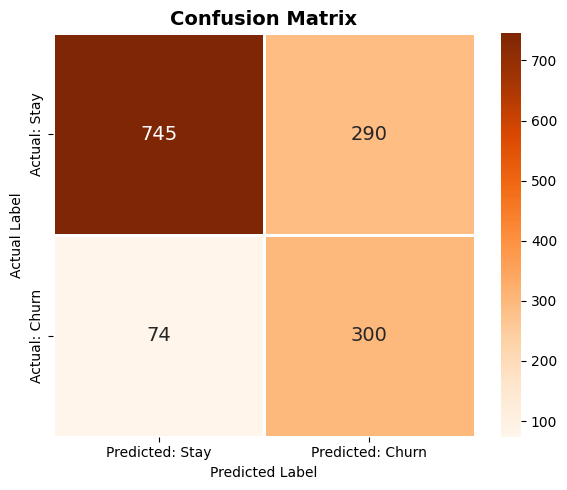

True Negatives  (correctly predicted STAY)  : 745
False Positives (predicted churn, actually stayed) : 290
False Negatives (predicted stay, actually churned) : 74  ← MISSED churners!
True Positives  (correctly predicted CHURN) : 300


In [44]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'],
            linewidths=2, linecolor='white', annot_kws={'size': 14})
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted STAY)  : {tn}")
print(f"False Positives (predicted churn, actually stayed) : {fp}")
print(f"False Negatives (predicted stay, actually churned) : {fn}  ← MISSED churners!")
print(f"True Positives  (correctly predicted CHURN) : {tp}")

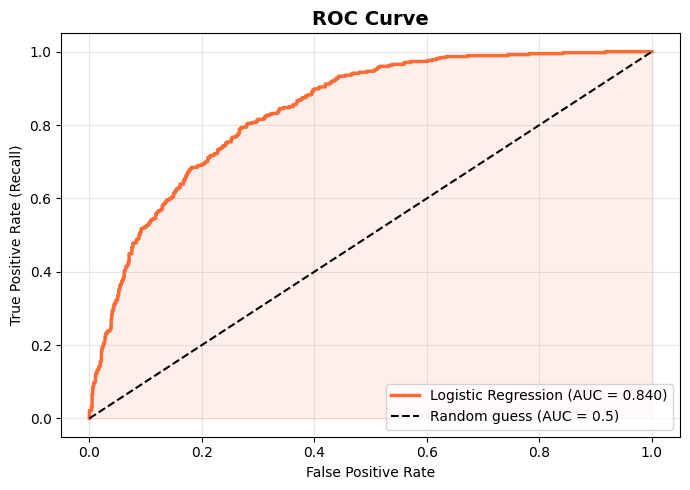

AUC-ROC = 0.840

The closer the curve is to the top-left corner, the better.
AUC > 0.8 is generally considered good for churn prediction.


In [45]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#FF6B35', lw=2.5,
        label=f'Logistic Regression (AUC = {auc_roc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random guess (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#FF6B35')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC-ROC = {auc_roc:.3f}")
print()
print("The closer the curve is to the top-left corner, the better.")
print("AUC > 0.8 is generally considered good for churn prediction.")

In [46]:
rf_model = RandomForestClassifier(
    n_estimators=300,    
    max_depth=8,          
    min_samples_leaf=4,   
    random_state=42,
    n_jobs=-1            
)

rf_model.fit(X_train_bal, y_train_bal)
rf_pred       = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc      = roc_auc_score(y_test, rf_pred_proba)

print("Random Forest Results:")
print(f"  Accuracy : {rf_accuracy:.4f}")
print(f"  AUC-ROC  : {rf_auc:.4f}")
print()
print("Logistic Regression Results (for comparison):")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  AUC-ROC  : {auc_roc:.4f}")

Random Forest Results:
  Accuracy : 0.7665
  AUC-ROC  : 0.8430

Logistic Regression Results (for comparison):
  Accuracy : 0.7417
  AUC-ROC  : 0.8401


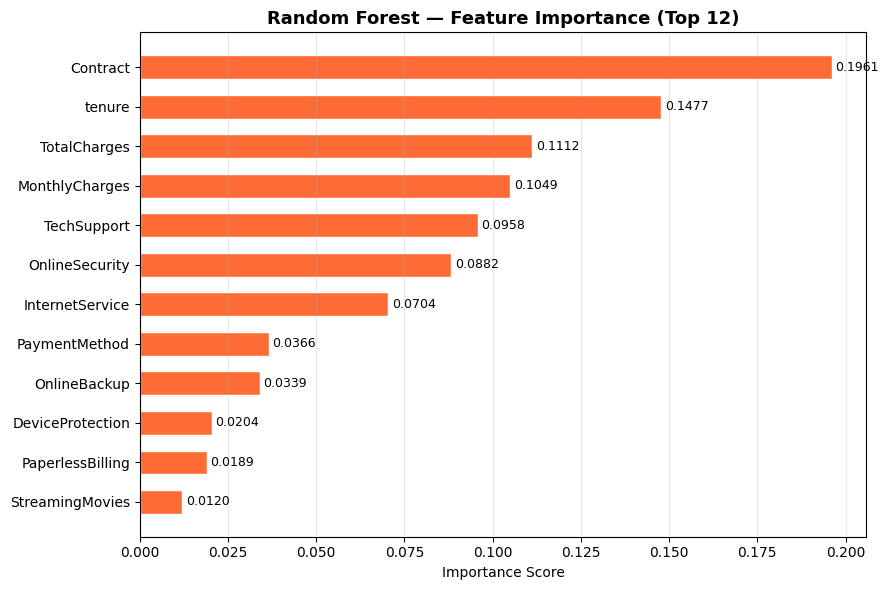


Features with higher importance have more influence on churn predictions.


In [47]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(feature_importance['Feature'][::-1],
               feature_importance['Importance'][::-1],
               color='#FF6B35', edgecolor='white', height=0.6)
for bar, val in zip(bars, feature_importance['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Random Forest — Feature Importance (Top 12)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print()
print("Features with higher importance have more influence on churn predictions.")

Model Comparison:
              Model  Accuracy  Precision   Recall  F1 Score  AUC-ROC
Logistic Regression  0.741661   0.508475 0.802139  0.622407 0.840071
      Random Forest  0.766501   0.541744 0.780749  0.639650 0.842980



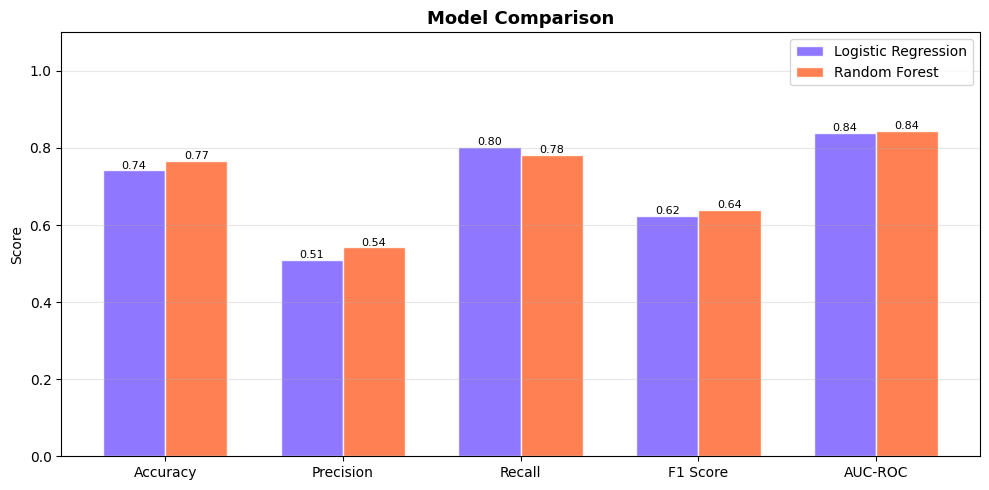

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred),    accuracy_score(y_test, rf_pred)],
    'Precision': [precision_score(y_test, y_pred),   precision_score(y_test, rf_pred)],
    'Recall':    [recall_score(y_test, y_pred),       recall_score(y_test, rf_pred)],
    'F1 Score':  [f1_score(y_test, y_pred),           f1_score(y_test, rf_pred)],
    'AUC-ROC':   [auc_roc,                            rf_auc],
})

print("Model Comparison:")
print(comparison.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(10, 5))
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
x        = np.arange(len(metrics))
width    = 0.35

bars1 = ax.bar(x - width/2, comparison.iloc[0][metrics], width,
               label='Logistic Regression', color='#7B61FF', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, comparison.iloc[1][metrics], width,
               label='Random Forest', color='#FF6B35', alpha=0.85, edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
df_biz = pd.read_csv(r"C:\Project\Custome_Churn_Predictor\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_biz['TotalCharges'] = pd.to_numeric(df_biz['TotalCharges'], errors='coerce')
df_biz['TotalCharges'] = df_biz['TotalCharges'].fillna(
    df_biz['MonthlyCharges'] * df_biz['tenure'])

df_enc_full = df.copy()
X_all = df_enc_full.drop(columns=['Churn'])
X_all_scaled = scaler.transform(X_all)

df_biz['churn_probability'] = rf_model.predict_proba(X_all_scaled)[:, 1]
df_biz['predicted_churn']   = (df_biz['churn_probability'] > 0.5).astype(int)

contract_months = {'Month-to-month': 8, 'One year': 18, 'Two year': 30}
df_biz['remaining_months'] = df_biz['Contract'].map(contract_months)
df_biz['revenue_at_risk']  = (
    df_biz['MonthlyCharges'] *
    df_biz['remaining_months'] *
    df_biz['predicted_churn']
)

df_biz['risk_segment'] = pd.cut(df_biz['churn_probability'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical'])

print("Revenue Impact Summary:")
print(f"  Predicted churners      : {df_biz['predicted_churn'].sum():,}")
print(f"  Total revenue at risk   : ${df_biz['revenue_at_risk'].sum():,.0f}")
print(f"  Avg revenue per churner : ${df_biz.loc[df_biz['predicted_churn']==1, 'revenue_at_risk'].mean():,.0f}")
print()
print("Revenue at risk by contract type:")
rev_by_contract = (df_biz[df_biz['predicted_churn']==1]
                   .groupby('Contract')['revenue_at_risk']
                   .sum()
                   .sort_values(ascending=False))
for contract, rev in rev_by_contract.items():
    print(f"  {contract:20s}: ${rev:>10,.0f}")

Revenue Impact Summary:
  Predicted churners      : 2,683
  Total revenue at risk   : $1,704,395
  Avg revenue per churner : $635

Revenue at risk by contract type:
  Month-to-month      : $ 1,559,946
  One year            : $   122,558
  Two year            : $    21,891


In [51]:
top_at_risk = (df_biz[df_biz['predicted_churn'] == 1]
               .sort_values('revenue_at_risk', ascending=False)
               [['customerID', 'Contract', 'tenure', 'MonthlyCharges',
                 'churn_probability', 'revenue_at_risk', 'risk_segment']]
               .head(10))

top_at_risk['churn_probability'] = top_at_risk['churn_probability'].map('{:.1%}'.format)
top_at_risk['revenue_at_risk']   = top_at_risk['revenue_at_risk'].map('${:,.0f}'.format)
top_at_risk['MonthlyCharges']    = top_at_risk['MonthlyCharges'].map('${:.2f}'.format)

print("Top 10 Highest-Risk Customers (prioritise these for retention calls):")
print(top_at_risk.to_string(index=False))

Top 10 Highest-Risk Customers (prioritise these for retention calls):
customerID Contract  tenure MonthlyCharges churn_probability revenue_at_risk risk_segment
3090-HAWSU Two year      61        $111.60             54.0%          $3,348         High
5089-IFSDP Two year      58        $109.45             50.6%          $3,284         High
5748-RNCJT Two year      69        $106.50             52.7%          $3,195         High
7762-URZQH Two year      66        $106.05             54.2%          $3,182         High
6680-NENYN Two year      43        $104.60             50.5%          $3,138         High
1527-SXDPN Two year      52         $96.25             53.2%          $2,888         High
1447-PJGGA Two year      57         $95.25             50.7%          $2,858         High
2403-BCASL One year      41        $111.95             58.4%          $2,015         High
9249-FXSCK One year      52        $111.25             54.0%          $2,002         High
7632-MNYOY One year      66   

##  Summary — 


| Step | What we did |
|------|-------------|
| 1 | Imported libraries |
| 2 | Loaded and explored the data |
| 3 | Understood the target variable (Churn) |
| 4 | Visual EDA — contract type, tenure, charges |
| 5 | Cleaned messy data (TotalCharges) |
| 6 | Encoded text columns to numbers |
| 7 | Split features (X) and target (y) |
| 8 | Train/test split (80/20) |
| 9 | Feature scaling (StandardScaler) |
| 10 | Fixed class imbalance via oversampling |
| 11 | Trained Logistic Regression |
| 12 | Made predictions |
| 13 | Evaluated with Accuracy, F1, AUC-ROC, Confusion Matrix |
| 14 | Trained Random Forest (more powerful) |
| 15 | Compared both models |
| 16 | Revenue impact analysis |

---

*Built with the IBM Telco Customer Churn dataset — 7,043 real customers*